# 超参数实验（以RNN为基础）
韩佳轩，23281106，计算机科学与技术学院

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import time
import numpy as np
import matplotlib.pyplot as plt

# 导入数据集和工具函数
from datasets import TrafficDataset, my_Dataset
from utils import train, test, visualize, plot_metric

In [10]:
torch.manual_seed(23281106)

## TorchRNN模型

In [11]:
class TorchRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=1, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.output(out), None  # 返回out和dummy hidden

In [12]:
# 超参数设置
sensor = 96
window_size = 12
batch_size = 64
hidden_size = 64
learning_rate = 0.001
num_epoch = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")   

Using device: cuda


In [13]:
# 数据加载,使用TrafficDataset
print("Loading dataset...")
dataset = TrafficDataset(sensor=96)
train_set, val_set, test_set = dataset.construct_set(
        train_por=0.6, test_por=0.2, window_size=window_size
    )
    
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False)
    
input_size = train_set.X.shape[-1] 
print(f"Input size: {input_size}, Samples: train={len(train_set)}, val={len(val_set)}, test={len(test_set)}")

Loading dataset...
Input size: 3, Samples: train=10701, val=3559, test=3560


In [14]:
# 反标准化函数（用于评估真实物理量）
def denormalize_fn(x):
    return dataset.denormalize(x.squeeze(-1))

In [15]:
def different_param_train(sensor, window_size, hidden_size, learning_rate, batch_size, num_epochs, device):
    print("Start training...")
    start_time = time.time()

    # 模型、损失、优化器
    model = TorchRNN(input_size=input_size, hidden_size=hidden_size, output_size=1).to(device)
    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_loss_lst, val_loss_lst, train_score_lst, val_score_lst, best_epoch = train(
            net=model,
            train_iter=train_loader,
            val_iter=val_loader,
            test_iter=test_loader,
            loss_fn=loss_fn,
            denormalize_fn=denormalize_fn,
            optimizer=optimizer,
            num_epoch=num_epoch,
            early_stop=10,
            device=device,
            output_model=None,          # 直接使用RNN最后一层输出
            is_print=True,
            is_print_batch=False
        )
        
    total_time = time.time() - start_time
    print(f"Training finished. Total time: {total_time:.2f}s")

        # 测试集最终评估
    test_score, test_loss = test(
            net=model,
            output_model=None,
            data_iter=test_loader,
            loss_fn=loss_fn,
            denormalize_fn=denormalize_fn,
            device=device
        )
    print("Final Test Result:")
    print(f"RMSE: {test_score[0]:.4f}   MAE: {test_score[1]:.4f}   MAPE: {test_score[2]:.2f}%")

    # 可视化损失和评分曲线
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_loss_lst, label='Train Loss')
    plt.plot(val_loss_lst, label='Val Loss')
    plt.title('Loss Curve (TorchRNN)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
        
    plt.subplot(1, 2, 2)
    score_array = np.array(train_score_lst)
    plt.plot(score_array[:, 0], label='Train RMSE')
    val_score_array = np.array(val_score_lst)
    plt.plot(val_score_array[:, 0], label='Val RMSE')
    plt.title('RMSE Curve (TorchRNN)')
    plt.xlabel('Epoch')
    plt.ylabel('RMSE')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'TorchRNN_training_curve_{sensor}_{window_size}_{hidden_size}_{learning_rate}_{batch_size}_{num_epoch}.png')
    plt.show()

Start training...
*** epoch1, train loss 0.0031, train rmse 51.1165, val loss 0.0005, val rmse 24.626554, time use 0.787s
*** epoch2, train loss 0.0004, train rmse 23.0418, val loss 0.0004, val rmse 22.097458, time use 0.632s
*** epoch3, train loss 0.0004, train rmse 22.9931, val loss 0.0004, val rmse 23.749894, time use 0.622s
*** epoch4, train loss 0.0004, train rmse 22.8415, val loss 0.0004, val rmse 21.003454, time use 0.635s
*** epoch5, train loss 0.0004, train rmse 22.3932, val loss 0.0005, val rmse 23.802279, time use 0.633s
*** epoch6, train loss 0.0004, train rmse 22.1457, val loss 0.0004, val rmse 20.996986, time use 0.764s
*** epoch7, train loss 0.0004, train rmse 22.6708, val loss 0.0004, val rmse 20.562368, time use 0.690s
*** epoch8, train loss 0.0004, train rmse 22.0173, val loss 0.0004, val rmse 20.965445, time use 0.617s
*** epoch9, train loss 0.0004, train rmse 21.9928, val loss 0.0004, val rmse 23.449170, time use 0.609s
*** epoch10, train loss 0.0004, train rmse 22.

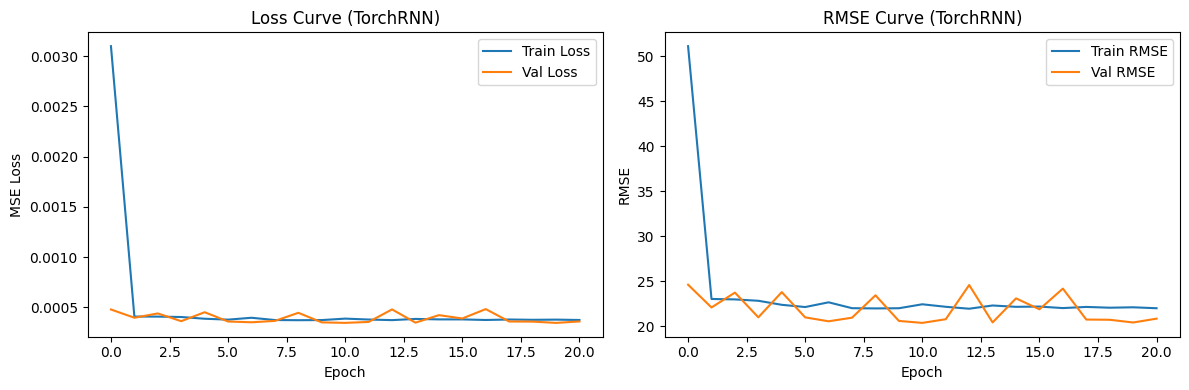

Change learning_rate to 0.0005 and start next training...
Start training...
*** epoch1, train loss 0.0030, train rmse 53.7053, val loss 0.0004, val rmse 21.890208, time use 0.790s
*** epoch2, train loss 0.0004, train rmse 22.7621, val loss 0.0004, val rmse 21.353059, time use 0.705s
*** epoch3, train loss 0.0004, train rmse 22.4226, val loss 0.0004, val rmse 21.662764, time use 0.621s
*** epoch4, train loss 0.0004, train rmse 22.7737, val loss 0.0004, val rmse 21.228997, time use 0.609s
*** epoch5, train loss 0.0004, train rmse 22.3360, val loss 0.0004, val rmse 21.207350, time use 0.536s
*** epoch6, train loss 0.0004, train rmse 22.0470, val loss 0.0004, val rmse 22.103376, time use 0.539s
*** epoch7, train loss 0.0004, train rmse 22.1781, val loss 0.0004, val rmse 21.647958, time use 0.760s
*** epoch8, train loss 0.0004, train rmse 22.1690, val loss 0.0004, val rmse 20.980882, time use 0.573s
*** epoch9, train loss 0.0004, train rmse 22.7126, val loss 0.0004, val rmse 22.846766, time

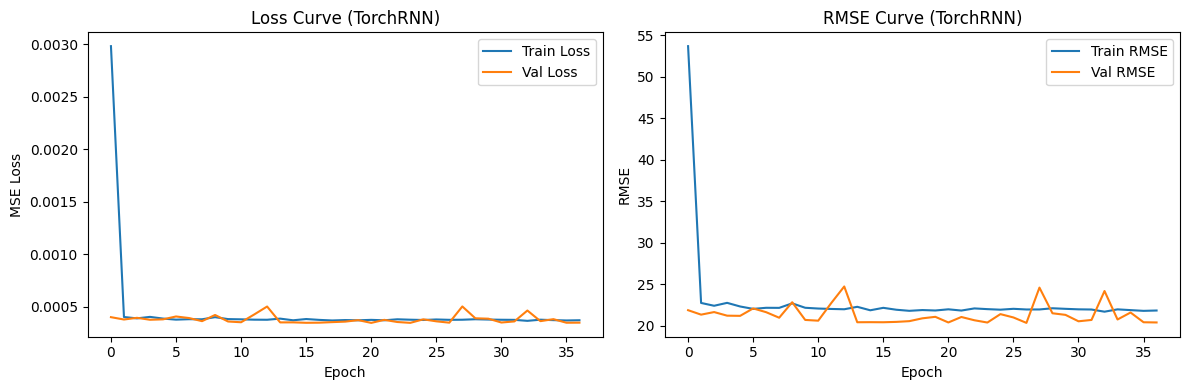

Change hidden_size to 128 and start next training...
Start training...
*** epoch1, train loss 0.0019, train rmse 41.9995, val loss 0.0004, val rmse 21.656332, time use 0.563s
*** epoch2, train loss 0.0004, train rmse 23.4848, val loss 0.0004, val rmse 20.789351, time use 0.689s
*** epoch3, train loss 0.0004, train rmse 22.7769, val loss 0.0004, val rmse 23.586814, time use 0.643s
*** epoch4, train loss 0.0004, train rmse 22.7546, val loss 0.0004, val rmse 22.312662, time use 0.707s
*** epoch5, train loss 0.0004, train rmse 22.7924, val loss 0.0004, val rmse 21.703823, time use 0.733s
*** epoch6, train loss 0.0004, train rmse 22.5251, val loss 0.0004, val rmse 22.119883, time use 0.639s
*** epoch7, train loss 0.0004, train rmse 22.1215, val loss 0.0003, val rmse 20.332386, time use 0.622s
*** epoch8, train loss 0.0004, train rmse 22.2258, val loss 0.0004, val rmse 20.873498, time use 0.656s
*** epoch9, train loss 0.0004, train rmse 22.0891, val loss 0.0004, val rmse 21.013123, time use 

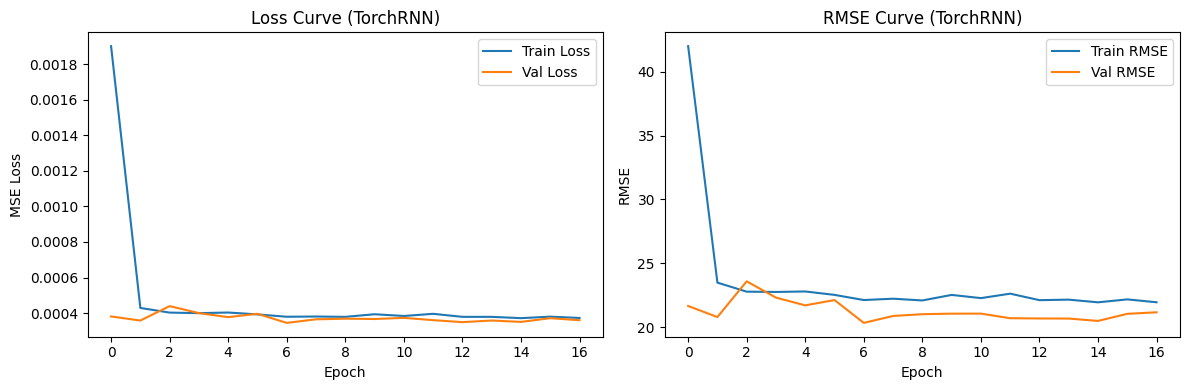

All trainings completed.


In [16]:
# 不同超参数训练
different_param_train(sensor, window_size, hidden_size, learning_rate, batch_size, num_epoch, device)

print("Change learning_rate to 0.0005 and start next training...")
different_param_train(sensor, window_size, hidden_size, 0.0005, batch_size, num_epoch, device)

print("Change hidden_size to 128 and start next training...")
different_param_train(sensor, window_size, 128, learning_rate, batch_size, num_epoch, device)

print("All trainings completed.")